>
---
Packages imports

In [ ]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Load your dataset
df = pd.read_csv('../data/ml_raw_data/diabetes.csv')

>
---
Data preprocessing & cleaning

In [57]:
# List of columns where 0 is invalid
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN, then fill with Median
for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print(df)    

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6    148.0           72.0           35.0    125.0  33.6   
1              1     85.0           66.0           29.0    125.0  26.6   
2              8    183.0           64.0           29.0    125.0  23.3   
3              1     89.0           66.0           23.0     94.0  28.1   
4              0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10    101.0           76.0           48.0    180.0  32.9   
764            2    122.0           70.0           27.0    125.0  36.8   
765            5    121.0           72.0           23.0    112.0  26.2   
766            1    126.0           60.0           29.0    125.0  30.1   
767            1     93.0           70.0           31.0    125.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

>
---
The Correlation Heatmap

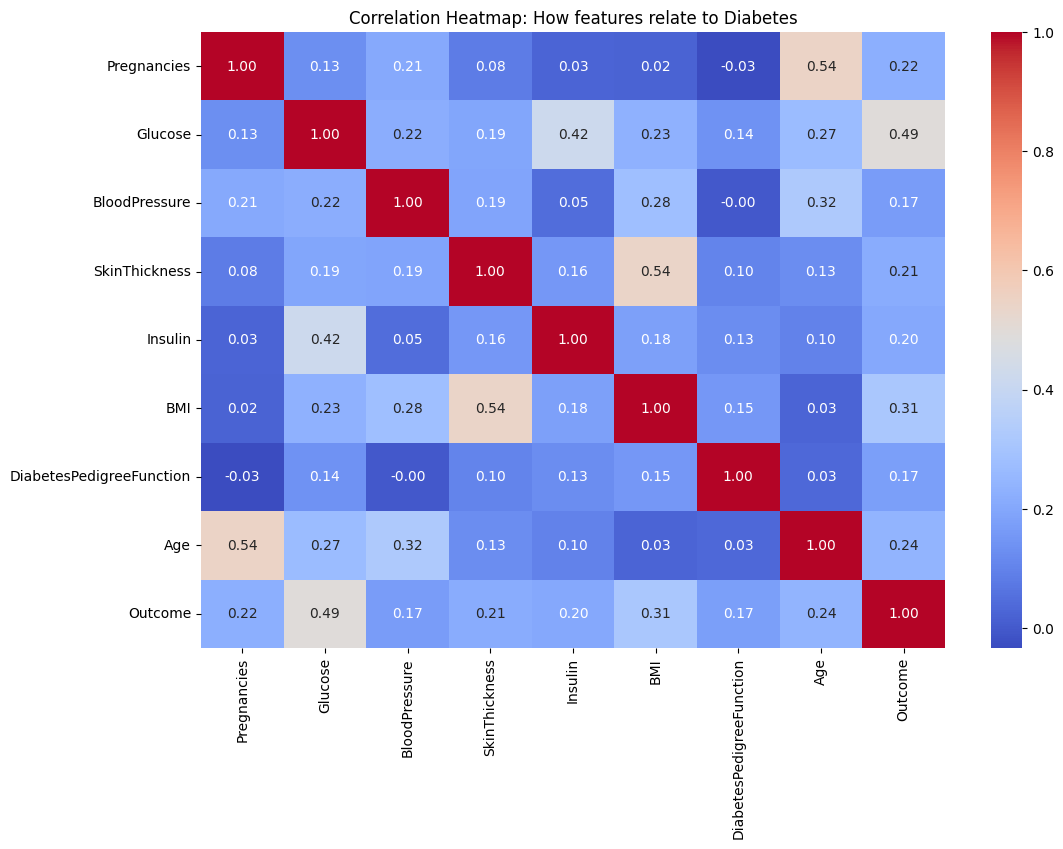

In [58]:
plt.figure(figsize=(12, 8))
# df.corr() calculates the correlation between all columns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: How features relate to Diabetes')
plt.show()

>
---
Data Scaling & splitting

In [59]:


X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# The data has 99 Healthy cases but only 55 Diabetic cases in the test set.
# APPLY SMOTE ONLY TO TRAINING DATA to fix the imbalance and prevent data leakage.
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training shape: {y_train.value_counts()}")
print(f"Balanced training shape: {y_train_balanced.value_counts()}")

Original training shape: Outcome
0    401
1    213
Name: count, dtype: int64
Balanced training shape: Outcome
0    401
1    401
Name: count, dtype: int64


>
---
Models training & evaluation

In [60]:
#RF, XGB,SVM

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced' ,random_state=42, max_depth=10),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

threshold = 0.34
for name, model in models.items():
    # Use the balanced training data for fitting
    model.fit(X_train_balanced, y_train_balanced)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    # Apply the custom threshold to get binary predictions
    custom_preds = (probs >= threshold).astype(int)
    # Print the full report
    print(f"\n================ {name} (Threshold: {threshold}) ================")
    print(classification_report(y_test, custom_preds, target_names=['Healthy', 'Diabetic']))

    # See the raw counts
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, custom_preds))


================ Random Forest (Threshold: 0.34) ================
              precision    recall  f1-score   support

     Healthy       0.91      0.63      0.74        99
    Diabetic       0.57      0.89      0.70        55

    accuracy                           0.72       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.72      0.73       154

Confusion Matrix:
[[62 37]
 [ 6 49]]

================ Logistic Regression (Threshold: 0.34) ================
              precision    recall  f1-score   support

     Healthy       0.88      0.58      0.70        99
    Diabetic       0.53      0.85      0.65        55

    accuracy                           0.68       154
   macro avg       0.70      0.72      0.67       154
weighted avg       0.75      0.68      0.68       154

Confusion Matrix:
[[57 42]
 [ 8 47]]

================ SVM (Threshold: 0.34) ================
              precision    recall  f1-score   support

     Healthy       0

>
---
Feature Importance Plot

C:\Users\user\AppData\Local\Temp\ipykernel_7212\346732590.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


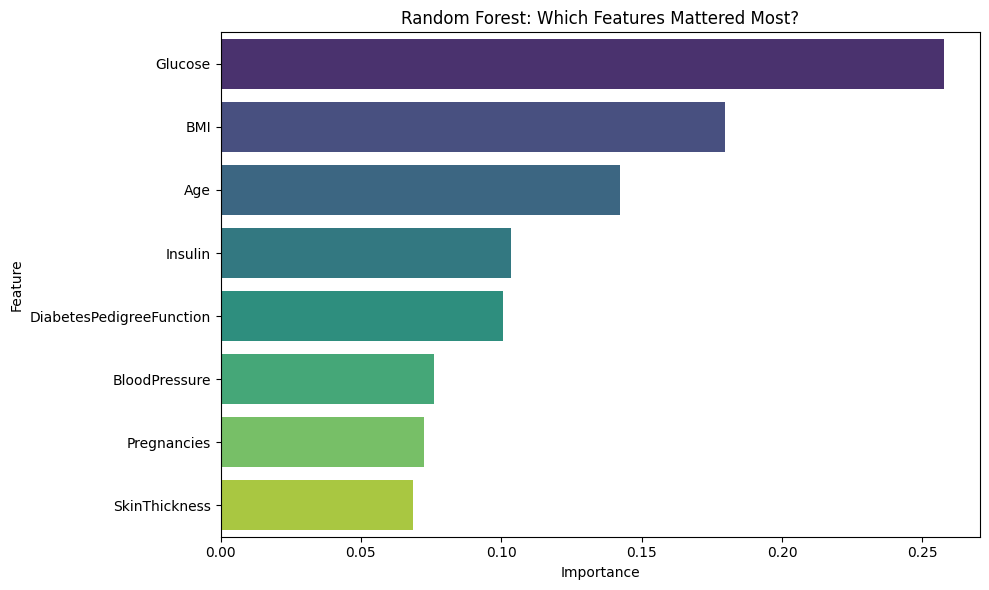

--- Logistic Regression ---
Note: SVM uses distance-based logic (Support Vectors) and doesn't provide a direct feature importance rank like trees do.

--- SVM ---
Note: SVM uses distance-based logic (Support Vectors) and doesn't provide a direct feature importance rank like trees do.



In [61]:

# We loop through existing "models" dictionary 
for name, model in models.items():
    # Only RF and XGBoost have the 'feature_importances_' attribute
    if hasattr(model, 'feature_importances_'):
        # Extract the importance scores
        importances = model.feature_importances_
        feature_names = X.columns
        
        # Organize them into a temporary DataFrame for the plot
        feat_imp_df = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        # Create the bar chart
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
        plt.title(f'{name}: Which Features Mattered Most?')
        plt.tight_layout()
        plt.show()
    else:
        # For SVM, we can print a note since it doesn't provide feature importance in the same way
        print(f"--- {name} ---")
        print("Note: SVM uses distance-based logic (Support Vectors) and doesn't provide a direct feature importance rank like trees do.\n")

>
---
Saving the model and the scaler

In [62]:
joblib.dump(models['Random Forest'], '../models/diabetes_model.pkl')
joblib.dump(scaler, '../models/diabetes_scaler.pkl')

print("\nSUCCESS: Best model and scaler saved to models/ folder!")


SUCCESS: Best model and scaler saved to models/ folder!
